# BFE radial force vs. time at different coefficient-sampling cadences

Ground truth: `perturbed_host`'s point-mass run (`runs/point_mass/point_mass_run_snapshots.h5`), a self-gravitating `N_host=1,000,000` Plummer host (`a_host=1`) relaxed for `t_relax=5`, then perturbed by a point-mass flyby dropped from apocenter `r_start=5` toward `r_peri=0.7` (Kepler orbital period `T ≈ 27.6`, first pericenter passage at `t ≈ 18.8`, recurring every `T` thereafter).

The science snapshots were written at `dt=0.1`. Since that only controls snapshot *write-out* cadence (the leapfrog integration itself runs at a fixed, independent `dt_int`), subsampling this single file at strides of 2/100/300 is equivalent to having rerun the simulation at `dt=0.2/10/30` — a fine cadence, a coarse one, and one coarser than the perturber's own orbital period.

**This notebook only reads and plots.** The expensive part — building the spherical (`sphereSL`) EXP basis and fitting BFE coefficients at each cadence (`basis.createFromArray` on up to 1,000,000 particles, per snapshot, per cadence) — was done by `perturbed_host_bfe_fit.py`, run as the SLURM job `prospero_submit_bfe_fit.sh`. If `runs/point_mass/bfe/` doesn't exist yet, submit that job first.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pyEXP
from tqdm.auto import tqdm

sys.path.insert(0, os.path.abspath("."))
import sampling_utils

In [2]:
SNAPSHOTS = "runs/point_mass/point_mass_run_snapshots.h5"
BFE_DIR = "runs/point_mass/bfe"
BASIS_YAML = os.path.join(BFE_DIR, "basis_sphereSL.yml")

# label -> stride on the dt=0.1 base file; must match perturbed_host_bfe_fit.py's --cadences run
CADENCES = {"0.2": 2, "10": 100, "30": 300}

T_RELAX = 5.0
T_ORB = 27.6
T_PERI0 = T_RELAX + 13.8  # first pericenter passage (absolute time)
PERICENTER_TIMES = [T_PERI0 + n * T_ORB for n in range(4)]

R_EVAL = 1.0  # one host scale radius (a_host)

## Load the pre-computed basis and per-cadence coefficients

In [3]:
with open(BASIS_YAML) as f:
    basis = pyEXP.basis.Basis.factory(f.read())

coefs = {
    label: pyEXP.coefs.Coefs.factory(os.path.join(BFE_DIR, f"coefs_dt{label}.h5"))
    for label in CADENCES
}
for label, c in coefs.items():
    print(f"dt={label}: {len(c.Times())} coefficient snapshots, "
          f"t in [{min(c.Times()):.2f}, {max(c.Times()):.2f}]")

---- SLGridSph::ReadH5Cache: successfully read basis cache <dt=0.2: 501 coefficient snapshots, t in [5.00, 105.00]
dt=10: 11 coefficient snapshots, t in [5.00, 105.00]
dt=30: 4 coefficient snapshots, t in [5.00, 95.00]
/mnt/aridata1/users/ariasant/streams_in_dreams/runs/point_mass/bfe/basis_sphereSL.cache.run0>
---- Spherical::orthoTest: worst=0.0011918


## Radial force at r = 1 vs. time, on one common uniform cadence

All three approximations are evaluated on a **single uniform time grid** (`EVAL_DT`), so the curves are
directly comparable point-for-point instead of each being sampled at its own snapshot times.
`sampling_utils.dpsi_dr` can only be evaluated at a cadence's *exact* stored snapshot times
(`coefs.getCoefStruct(t)`), so the force here is read from each cadence's `gp.EXPPotential` instead
— `pot.gradient([r, 0, 0], t)` gives the Cartesian `∇Φ`, which is projected onto the radial unit
vector `RHAT` to get `dψ/dr` at `r = R_EVAL`, and the potential interpolates that cadence's stored
coefficients in time. This is the *same* time-dependent potential used for the orbit integrations
below, so a coarse cadence's curve shows exactly how well its handful of stored coefficient snapshots,
interpolated onto the fine grid, reproduce the force. Each cadence is only sampled within its own
coefficient time span (`dt=30` stops at `t=95`).

The **black line** is the direct N-body ground truth these BFE curves approximate: a massless test
particle is placed at the *same* probe point (host-COM-frame `[R_EVAL, 0, 0]`) and feels the exact
`pytreegrav` gravitational pull of **all** other particles in the system (host + perturber), softened
with the simulation's `eps = 0.05`. `pytreegrav` returns a Cartesian acceleration, so it is projected
onto the same radial unit vector `RHAT` (`-a_r = dψ/dr`, matching the BFE sign). To keep it cheap the
direct force is evaluated only at the snapshots that fall on the common comparison grid (not at every
`dt=0.1` snapshot). The pipeline was checked against an isolated Plummer sphere: the direct radial force
at `r = 1` recovers the analytic `M r / (r² + a²)^{3/2} ≈ 0.354` to <1%. Because the plotted curve also
includes the perturber's *direct* attraction — which the host-only BFE never models — it departs
sharply from the BFE curves near pericenter passages where the flyby swings close to the probe. (Set
`INCLUDE_PERTURBER = False` in the cell above for the pure host reference, which should track the BFE
curves closely, especially before the first pericenter when the perturber is still far away.)

Two marker shapes distinguish the two sets of BFE times: **open circles** sit on the common `EVAL_DT`
grid every cadence is sampled on, while **stars** mark the times where that cadence's coefficients were
actually determined (fit) — evaluated exactly there, with no time interpolation. The span between a
cadence's stars is therefore what the circles in between have to interpolate across (obvious for `dt=30`,
with only four stars; dense for `dt=0.2`, whose coefficients are fit every 0.2). Dotted vertical lines
mark the perturber's pericenter passages; the grey band is Phase A relaxation (before the perturber
exists).

In [4]:
import h5py
from pytreegrav import AccelTarget

# Direct N-body "ground truth" the BFE curves approximate: drop a massless test particle one scale
# radius from the host centre -- at the SAME point the BFE force is probed, host-COM-frame
# [R_EVAL, 0, 0] -- and sum the exact gravitational pull of the other particles in the system with
# pytreegrav. To keep this cheap, it is evaluated ONLY at the snapshots that land on the common
# comparison grid (`EVAL_DT`, a subset of the dt=0.1 snapshot cadence), not at every snapshot.
EPS = 0.05  # softening; matches config_point_mass.yaml eps_host = eps_pert (uniform)
PROBE_OFFSET = np.array([R_EVAL, 0.0, 0.0])  # host-COM-frame probe position
RHAT = PROBE_OFFSET / np.linalg.norm(PROBE_OFFSET)  # radial unit vector at the probe (from host centre)
INCLUDE_PERTURBER = False  # sources = all particles; set False for the pure host-only reference
EVAL_DT = 5.0  # common comparison cadence, shared with the radial-force plot below

# The shared uniform grid, spanning the full (dt=0.2) coefficient time range.
grid = np.arange(coefs["0.2"].Times()[0], coefs["0.2"].Times()[-1] + 0.5 * EVAL_DT, EVAL_DT)

_com = np.load(os.path.join(BFE_DIR, "host_com.npz"))
_com_t, _com_pos = _com["time"], _com["com"]

def _com_at(t):
    """Host centre-of-mass at time t (same per-snapshot recentering the BFE was fit in)."""
    return np.array([np.interp(t, _com_t, _com_pos[:, i]) for i in range(3)])

direct_t, direct_force = [], []
with h5py.File(SNAPSHOTS, "r") as f:
    snap_names = sorted(k for k in f if k.startswith("snap_"))
    snap_times = np.array([f[n].attrs["time"] for n in snap_names])  # metadata only, cheap
    # Nearest snapshot to each grid time (the grid is a subset of the dt=0.1 snapshot cadence).
    sel = np.unique(np.abs(snap_times[:, None] - grid[None, :]).argmin(axis=0))
    for i in sel:
        g = f[snap_names[i]]
        t = float(g.attrs["time"])
        mask = slice(None) if INCLUDE_PERTURBER else ~g["is_perturber"][:]
        src_pos, src_mass = g["pos"][:][mask], g["mass"][:][mask]
        target = (_com_at(t) + PROBE_OFFSET)[None, :]
        a = AccelTarget(target, src_pos, src_mass,
                        softening_target=np.array([EPS]),
                        softening_source=np.full(src_mass.shape, EPS),
                        G=1.0, method="bruteforce", parallel=True)
        # pytreegrav returns a Cartesian acceleration vector; project it onto the radial direction.
        a_r = float(np.dot(a[0], RHAT))
        direct_t.append(t)
        direct_force.append(-a_r)  # -a_r = dpsi/dr at the probe, matching the BFE curves' sign

direct_t = np.array(direct_t)
direct_force = np.array(direct_force)
print(f"direct force computed at {len(direct_t)} snapshots (of {len(snap_names)}), "
      f"t in [{direct_t.min():.2f}, {direct_t.max():.2f}]")

direct force computed at 21 snapshots (of 1001), t in [5.00, 105.00]


<>:57: SyntaxWarning: invalid escape sequence '\P'
<>:57: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_525343/1515944920.py:57: SyntaxWarning: invalid escape sequence '\P'
  ax.set_ylabel(f"$-\\nabla~\Phi(r={R_EVAL})$")


---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/aridata1/users/ariasant/streams_in_dreams/runs/point_mass/bfe/basis_sphereSL.cache.run0>
---- Spherical::orthoTest: worst=0.0011918
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/aridata1/users/ariasant/streams_in_dreams/runs/point_mass/bfe/basis_sphereSL.cache.run0>
---- Spherical::orthoTest: worst=0.0011918
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/aridata1/users/ariasant/streams_in_dreams/runs/point_mass/bfe/basis_sphereSL.cache.run0>
---- Spherical::orthoTest: worst=0.0011918


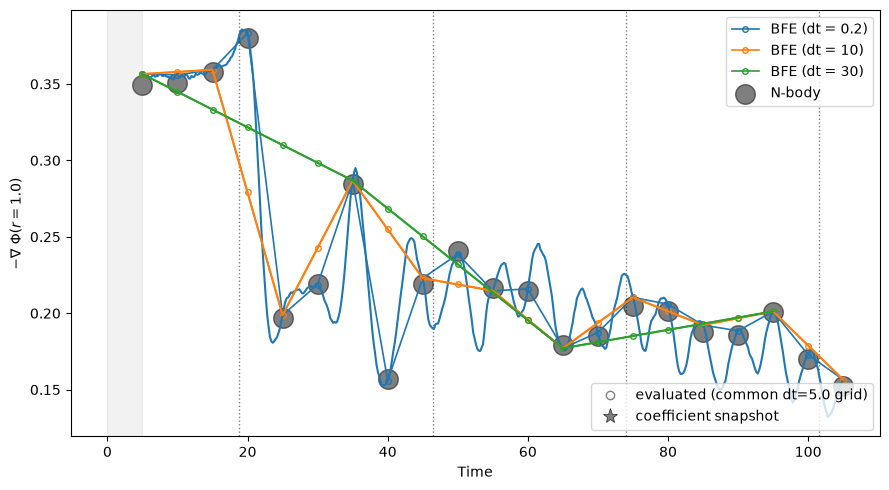

In [6]:
import gala.potential as gp
from gala.units import DimensionlessUnitSystem
from matplotlib.lines import Line2D

# Build each cadence's time-dependent BFE potential once (reused by the orbit section below).
# gala's EXPPotential interpolates a cadence's stored coefficients in time, so -- unlike
# sampling_utils.dpsi_dr, which only works at the exact snapshot times each cadence stored --
# all three approximations can be sampled on one common, uniform time grid.
pots = {
    label: gp.EXPPotential(units=DimensionlessUnitSystem(),
                           config_file=BASIS_YAML,
                           coef_file=os.path.join(BFE_DIR, f"coefs_dt{label}.h5"))
    for label in CADENCES
}

# EVAL_DT (the common uniform cadence), PROBE_OFFSET and RHAT are defined in the direct-force cell.
def radial_force(label, times):
    """dpsi/dr at r = R_EVAL: the BFE gradient projected onto the radial unit vector RHAT."""
    return np.array([float(np.dot(np.asarray(pots[label].gradient(PROBE_OFFSET, t=t)).flatten(), RHAT))
                     for t in times])

def grid_times(label):
    """The common uniform grid, clipped to this cadence's coefficient time span."""
    t0, t1 = coefs[label].Times()[0], coefs[label].Times()[-1]
    return np.arange(t0, t1 + 0.5 * EVAL_DT, EVAL_DT)

fig, ax = plt.subplots(figsize=(9, 5))

cadence_handles = []
for label in CADENCES:
    # Line + open circles: the shared uniform grid the force is sampled on.
    times = grid_times(label)
    line, = ax.plot(times, radial_force(label, times), lw=1.2,
                    marker="o", ms=4, mfc="none", label=f"BFE (dt = {label})")
    cadence_handles.append(line)
    # Stars: the times where this cadence's coefficients were actually determined (fit) --
    # evaluated exactly there, with no time interpolation. The span between stars is what the
    # circles above have to interpolate across.
    coef_t = np.array(coefs[label].Times())
    ax.plot(coef_t, radial_force(label, coef_t), ls="-", 
            color=line.get_color(), 
            #marker="*", ms=11,
            #markeredgecolor="k", markeredgewidth=0.4, 
            zorder=5)

# Direct N-body force (pytreegrav) at the same probe point -- the ground truth, black, no markers.
direct_handle = ax.scatter(direct_t, direct_force, color="k", s=200, zorder=1,
                           alpha=0.5, label="N-body")

t_max = max(coefs["0.2"].Times())
for tp in PERICENTER_TIMES:
    if tp <= t_max:
        ax.axvline(tp, color="k", ls=":", lw=1, alpha=0.5)
ax.axvspan(0, T_RELAX, color="grey", alpha=0.1)

ax.set_xlabel("Time")
ax.set_ylabel(f"$-\\nabla~\Phi(r={R_EVAL})$")

# Two legends: one for the curves, one explaining the marker shapes.
marker_handles = [
    Line2D([0], [0], color="grey", marker="o", mfc="none", ls="none",
           label=f"evaluated (common dt={EVAL_DT} grid)"),
    Line2D([0], [0], color="grey", marker="*", ls="none", ms=11,
           markeredgecolor="k", markeredgewidth=0.4, label="coefficient snapshot"),
]
leg1 = ax.legend(handles=cadence_handles + [direct_handle], loc="upper right")
ax.add_artist(leg1)
ax.legend(handles=marker_handles, loc="lower right")

fig.tight_layout()
fig.savefig("perturbed_host_bfe_force_vs_time.png", dpi=200)

## Test-particle orbit: integrated in each cadence's potential vs. the actual N-body trajectory

A force-vs-time mismatch is convincing on its own, but the point of the cadence experiment is
what it does to an *orbit*. Pick one host particle whose phase-space position at injection
(`t=T_RELAX`, i.e. `snap_0000`) is close to `pos=[1,0,0]`, `vel=[0,1,0]`, integrate a test-particle
orbit from there in each cadence's `gp.EXPPotential` (same pattern as
`plummer_sphere_stream_sim.ipynb`: `DimensionlessUnitSystem()`, `gd.PhaseSpacePosition`,
`gi.DOPRI853Integrator`), and compare against that *same particle's* actual trajectory read
directly from the snapshots. `dt=30`'s coefficients only run to `t=95` (`105` isn't an exact
multiple of its stride), so its orbit is correspondingly shorter.

**Host center-of-mass drift.** The perturber is a fifth of the host's mass and gives it a real
gravitational recoil — `perturbed_host_bfe_fit.py`'s `compute_host_com` shows host `|COM|` growing
from ~0.003 at injection to ~4 (four scale radii) by the end of the run. The basis coefficients
are fit on host positions recentered on this per-snapshot COM (matching the reference notebooks'
`pynbody.analysis.center(..., with_velocity=False)`), so the resulting `EXPPotential` is defined
in the host's own comoving frame, not the lab frame. Orbits are integrated in that same
comoving frame (IC position shifted by the COM at injection) and shifted back to lab-frame
coordinates — using `host_com.npz`, linearly interpolated onto the orbit's own time grid — only
for plotting/comparison against the true (lab-frame) trajectory.

In [6]:
import h5py

com_data = np.load(os.path.join(BFE_DIR, "host_com.npz"))
com_t, com_pos = com_data["time"], com_data["com"]

def interp_vec(t_eval, t_grid, values):
    """Linearly interpolate a (N,3) vector time series onto arbitrary query times."""
    return np.column_stack([np.interp(t_eval, t_grid, values[:, i]) for i in range(3)])

TARGET_POS = np.array([1.0, 0.0, 0.0])
TARGET_VEL = np.array([0.0, 1.0, 0.0])

with h5py.File(SNAPSHOTS, "r") as f:
    names_all = sorted(k for k in f if k.startswith("snap_"))
    g0 = f[names_all[0]]
    pos0, vel0, flag0 = g0["pos"][:], g0["vel"][:], g0["is_perturber"][:]
    t_inject = float(g0.attrs["time"])

host_idx = np.flatnonzero(~flag0)
com0 = com_pos[0]  # host COM at injection -- matches snap_0000, used to fit the basis
# Match the target IC in the host-COM-relative frame (position only), consistent with how the
# basis coefficients were fit (see perturbed_host_bfe_fit.py's compute_host_com/read_host_snapshot).
d2 = (np.sum((pos0[host_idx] - com0 - TARGET_POS) ** 2, axis=1)
      + np.sum((vel0[host_idx] - TARGET_VEL) ** 2, axis=1))
particle_idx = int(host_idx[np.argmin(d2)])
ic_pos, ic_vel = pos0[particle_idx].copy(), vel0[particle_idx].copy()
print(f"Tracking particle {particle_idx} at t={t_inject}: pos0={ic_pos}, vel0={ic_vel}, "
      f"host COM={com0}")

# That particle's actual (lab-frame) trajectory, read one row at a time from every dt=0.1
# snapshot (a single-row read, not the full 1,000,000-particle array, so this stays cheap).
true_t = np.empty(len(names_all))
true_pos = np.empty((len(names_all), 3))
with h5py.File(SNAPSHOTS, "r") as f:
    for i, name in enumerate(names_all):
        g = f[name]
        true_t[i] = g.attrs["time"]
        true_pos[i] = g["pos"][particle_idx]

Tracking particle 867854 at t=5.0: pos0=[ 0.81016836 -0.08052459  0.1340128 ], vel0=[0.01682639 0.90526289 0.06560988], host COM=[-0.0009167   0.00246453  0.0001196 ]


In [7]:
import gala.dynamics as gd
import gala.integrate as gi

# Integrate in the host-COM-relative frame the recentered coefficients are defined in: ic_pos is
# shifted by the host's COM at injection. ic_vel is left as-is, matching the position-only
# recentering convention used when fitting coefficients (with_velocity=False). Reuses the same
# per-cadence gp.EXPPotential objects (`pots`) built for the radial-force plot above.
# atol is relaxed from gala's (very tight) adaptive default: the EXP force field is
# numerically evaluated (SL-grid interpolation), not perfectly smooth, and the default
# tolerance makes DOPRI853 stall chasing that noise instead of converging.
w0 = gd.PhaseSpacePosition(pos=ic_pos - com0, vel=ic_vel)

orbits = {}
for label in CADENCES:
    pot = pots[label]
    t1, t2 = coefs[label].Times()[0], coefs[label].Times()[-1]
    orbits[label] = pot.integrate_orbit(w0, t1=t1, t2=t2, n_steps=2000,
                                        Integrator=gi.DOPRI853Integrator,
                                        Integrator_kwargs={"atol": 1e-4})
    print(f"dt={label}: integrated t in [{t1:.1f}, {t2:.1f}]")

dt=0.2: integrated t in [5.0, 105.0]
dt=10: integrated t in [5.0, 105.0]
dt=30: integrated t in [5.0, 95.0]


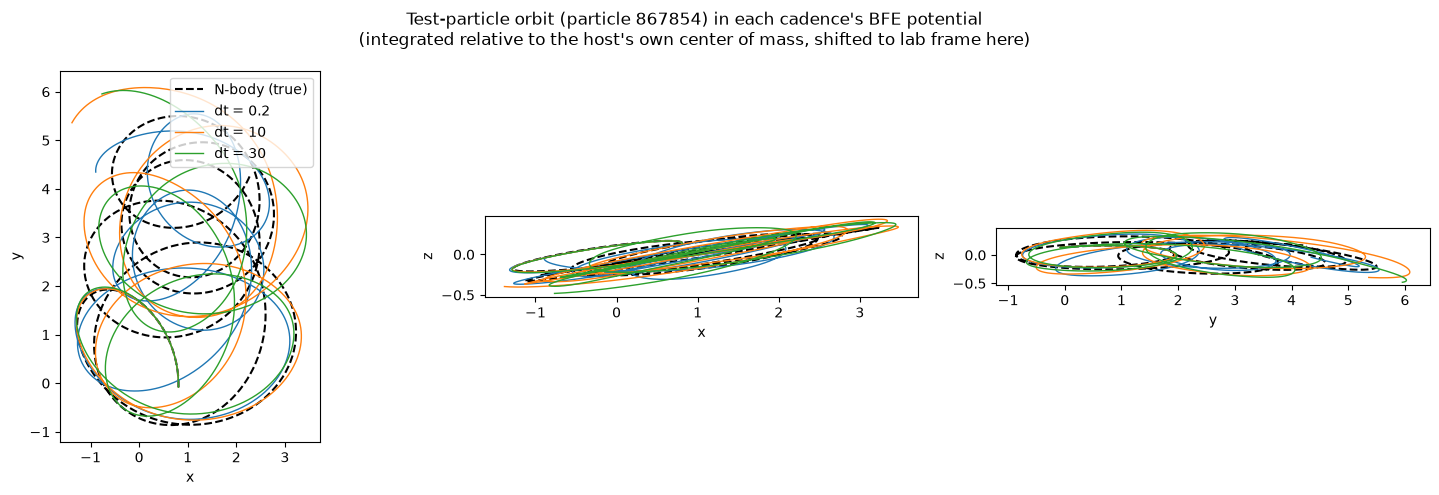

In [8]:
CADENCE_COLORS = {"0.2": "C0", "10": "C1", "30": "C2"}
PROJECTIONS = [("x", "y"), ("x", "z"), ("y", "z")]
AXIS_IDX = {"x": 0, "y": 1, "z": 2}

def orbit_lab_frame(orbit):
    """Shift a host-COM-relative integrated orbit back to lab-frame coordinates."""
    t = np.asarray(orbit.t)
    xyz_rel = np.column_stack([np.asarray(orbit.x), np.asarray(orbit.y), np.asarray(orbit.z)])
    return t, xyz_rel + interp_vec(t, com_t, com_pos)

orbits_lab = {label: orbit_lab_frame(orbits[label]) for label in CADENCES}

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for (a, b), ax in zip(PROJECTIONS, axs):
    ax.plot(true_pos[:, AXIS_IDX[a]], true_pos[:, AXIS_IDX[b]],
           color="k", ls="--", lw=1.5, label="N-body (true)")
    for label in CADENCES:
        _, xyz = orbits_lab[label]
        ax.plot(xyz[:, AXIS_IDX[a]], xyz[:, AXIS_IDX[b]],
               color=CADENCE_COLORS[label], lw=1, label=f"dt = {label}")
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_aspect("equal")
axs[0].legend()
fig.suptitle(f"Test-particle orbit (particle {particle_idx}) in each cadence's BFE potential\n"
             "(integrated relative to the host's own center of mass, shifted to lab frame here)")
fig.tight_layout()
fig.savefig("perturbed_host_bfe_orbit_comparison.png", dpi=150)

### Residuals: planar separation from the true orbit, vs. time

For each projection plane, `sqrt((a - a_true)^2 + (b - b_true)^2)` at every point along each
cadence's integrated orbit, with the true trajectory linearly interpolated (from its native
`dt=0.1` sampling) onto that orbit's own integration times.

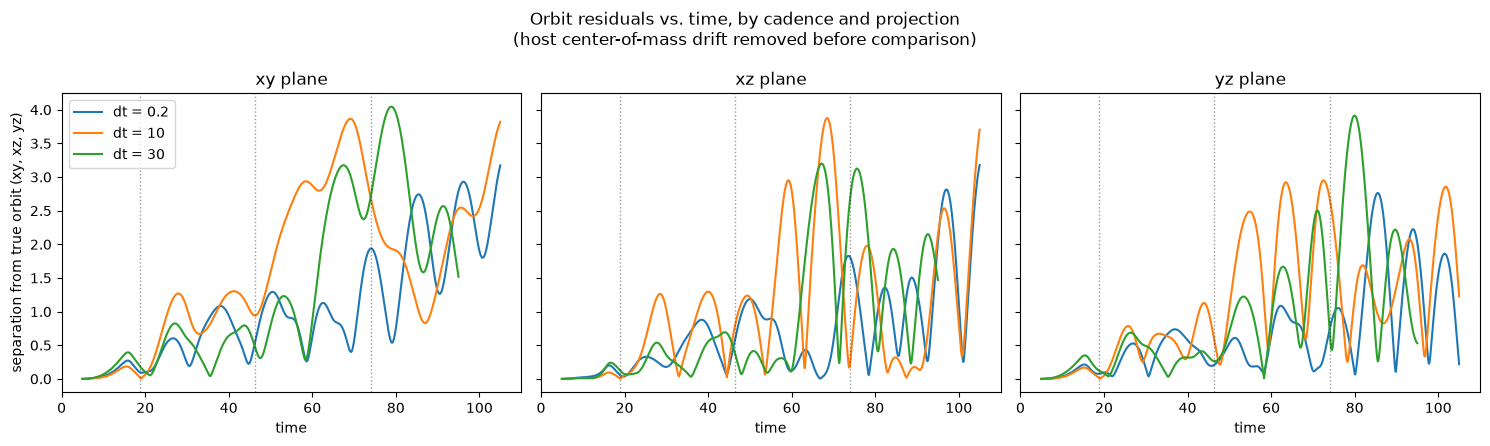

In [9]:
def true_pos_at(t_eval):
    return interp_vec(t_eval, true_t, true_pos)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for (a, b), ax in zip(PROJECTIONS, axs):
    for label in CADENCES:
        t_orbit, xyz_lab = orbits_lab[label]
        true_interp = true_pos_at(t_orbit)
        resid = np.sqrt((xyz_lab[:, AXIS_IDX[a]] - true_interp[:, AXIS_IDX[a]]) ** 2
                        + (xyz_lab[:, AXIS_IDX[b]] - true_interp[:, AXIS_IDX[b]]) ** 2)
        ax.plot(t_orbit, resid, color=CADENCE_COLORS[label], label=f"dt = {label}")
    for tp in PERICENTER_TIMES:
        if tp <= t_orbit.max():
            ax.axvline(tp, color="k", ls=":", lw=1, alpha=0.4)
    ax.set_xlabel("time")
    ax.set_title(f"{a}{b} plane")
axs[0].set_ylabel(f"separation from true orbit ({', '.join(a+b for a, b in PROJECTIONS)})")
axs[0].legend()
fig.suptitle("Orbit residuals vs. time, by cadence and projection\n"
             "(host center-of-mass drift removed before comparison)")
fig.tight_layout()
fig.savefig("perturbed_host_bfe_orbit_residuals.png", dpi=150)

## Ensemble test: does a bad force approximation directly translate to a bad orbit approximation?

The force-vs-time comparison above (fixed probe `R_EVAL = 1`) and the single test-particle orbit
are each one point in a much larger population of possible answers. This section repeats the
exercise over 1000 particles sampled from the host at injection, to see whether the
cadence-dependent force error established above actually predicts anything about *orbital
element* errors -- and whether that answer depends on the orbit's own pericentre/eccentricity.

For each of 1000 sampled host particles:

1. **Orbit approximation.** Integrate from the particle's injection-time phase-space position
   in each cadence's `gp.EXPPotential` (same host-COM-relative frame as the single-particle
   integration above, same relaxed `atol=1e-4`), over the time span common to all three
   cadences -- `t in [T_RELAX, 95]`, set by `dt=30`'s shorter coefficient span. Pericentre,
   apocentre and eccentricity are read off with the same `orbit.pericenter()` /
   `.apocenter()` / `.eccentricity()` gala machinery used for the analytic-vs-EXP comparison in
   `plummer_bfe_report.ipynb`.
2. **True orbit.** The same particle's actual trajectory, read directly from every `dt=0.1`
   snapshot over that same window and recentred on the host COM (`host_com.npz`), is wrapped in
   a `gd.Orbit` so the *identical* pericentre/apocentre/eccentricity estimator applies to ground
   truth and approximation alike -- any difference is real, not an artifact of two different
   estimators.
3. **Force error.** The radial force error is measured **at the particle's true position**, not
   along each cadence's own (already integrated, already-drifting) orbit -- evaluating it along
   the approximate orbit would conflate force error with the orbit-integration error it's
   supposed to explain. Each cadence's `gp.EXPPotential` gradient is evaluated at the true
   position on the common `EVAL_DT` grid and compared to the direct N-body radial force
   (`pytreegrav`, host-only sources, same convention as the fixed-probe comparison above) at
   that same true position and time. The Euclidean distance between the two radial-force time
   series is a single scalar per particle per cadence: how wrong this cadence's force field is
   along the path the particle actually took, decoupled from any orbit-integration error.


In [10]:
# Cache the expensive parts of this ensemble analysis (orbit integration, the ~900-snapshot
# reads, the direct N-body force evaluation, the DWT) so that adding one more statistic doesn't
# mean waiting ~20 minutes again -- every cell below either fills in these variables by loading
# them from this cache or, on the first run, computes them and the save cell (at the end of the
# ensemble section) writes the cache for next time. Delete this file to force a full recompute
# (e.g. after changing N_SAMPLE, the sampling seed, or T_COMMON_MAX upstream).
CACHE_FILE = os.path.join(BFE_DIR, "ensemble_cache.npz")
HAVE_CACHE = os.path.exists(CACHE_FILE)
_cache = dict(np.load(CACHE_FILE)) if HAVE_CACHE else {}
print(f"ensemble cache {'found' if HAVE_CACHE else 'not found'} at {CACHE_FILE}")


ensemble cache found at runs/point_mass/bfe/ensemble_cache.npz


In [11]:
# Ensemble of 1000 host particles, sampled at injection (t = T_RELAX, snap_0000), reusing the
# pos0/vel0/flag0/host_idx/com0/t_inject already loaded above for the single test particle.
N_SAMPLE = 1000
rng = np.random.default_rng(42)
sample_idx = np.sort(rng.choice(host_idx, size=N_SAMPLE, replace=False))

ic_pos_ens = pos0[sample_idx]  # lab-frame, at injection
ic_vel_ens = vel0[sample_idx]

# Host-COM-relative frame, same convention as the single-particle w0 above.
w0_ens = gd.PhaseSpacePosition(pos=(ic_pos_ens - com0).T, vel=ic_vel_ens.T)
print(f"Sampled {N_SAMPLE} host particles at t={t_inject}")


Sampled 1000 host particles at t=5.0


In [12]:
# Common time span across all three cadences -- dt=30's coefficients are the limiting factor
# (they stop at t=95; see the "dt=30 stops at t=95" note on the radial-force plot above).
T_COMMON_MAX = min(coefs[label].Times()[-1] for label in CADENCES)

if not HAVE_CACHE:
    orbits_ens = {}
    for label in CADENCES:
        orbits_ens[label] = pots[label].integrate_orbit(
            w0_ens, t1=t_inject, t2=T_COMMON_MAX, n_steps=2000,
            Integrator=gi.DOPRI853Integrator, Integrator_kwargs={"atol": 1e-4})
        print(f"dt={label}: integrated {N_SAMPLE} orbits over t in [{t_inject}, {T_COMMON_MAX}]")

    # Local-minima/maxima finding in r(t) returns nan for particles that never complete a full
    # radial oscillation within the common window (e.g. very wide, slowly-orbiting particles);
    # harmless here, just masked out before plotting below.
    peri_approx = {label: np.asarray(orbits_ens[label].pericenter()) for label in CADENCES}
    apo_approx = {label: np.asarray(orbits_ens[label].apocenter()) for label in CADENCES}
    ecc_approx = {label: np.asarray(orbits_ens[label].eccentricity()) for label in CADENCES}
else:
    orbits_ens = None  # not needed on a cache hit -- see the DWT-grid cell below
    peri_approx = {label: _cache[f"peri_approx_{label}"] for label in CADENCES}
    apo_approx = {label: _cache[f"apo_approx_{label}"] for label in CADENCES}
    ecc_approx = {label: _cache[f"ecc_approx_{label}"] for label in CADENCES}
    print("loaded orbit-integration results (peri/apo/ecc) from cache")


loaded orbit-integration results (peri/apo/ecc) from cache


### True trajectory and radial force, read directly from the snapshots

Same per-row-cheap reading pattern as the single-particle cell above, just for 1000 particles
at once and reusing the full `dt=0.1` snapshot range (`snap_times`, from the direct-force cell
near the top) instead of re-deriving it. This cell is the expensive one -- ~900 snapshot reads
-- and takes several minutes.


In [13]:
if not HAVE_CACHE:
    # True trajectory for the same 1000 particles, read from every dt=0.1 snapshot spanning the
    # same common window, recentred on the host COM (host_com.npz) so the SAME
    # pericentre/apocentre/eccentricity estimator as the approximations (above) applies to
    # ground truth too.
    sel_ens = np.flatnonzero((snap_times >= t_inject - 1e-9) & (snap_times <= T_COMMON_MAX + 1e-9))
    true_t_ens = snap_times[sel_ens]

    true_pos_ens_lab = np.empty((len(sel_ens), N_SAMPLE, 3))
    with h5py.File(SNAPSHOTS, "r") as f:
        for j, i in enumerate(tqdm(sel_ens, desc="reading true trajectories")):
            true_pos_ens_lab[j] = f[names_all[i]]["pos"][sample_idx]

    com_series_ens = interp_vec(true_t_ens, com_t, com_pos)
    true_pos_ens_rel = true_pos_ens_lab - com_series_ens[:, None, :]

    # gd.Orbit wants pos shaped (3, n_times, n_orbits); velocity is unused by pericenter()/
    # apocenter() (they only look at the r(t) spline) so a zero array is fine here.
    true_orbit_ens = gd.Orbit(pos=np.transpose(true_pos_ens_rel, (2, 0, 1)),
                              vel=np.zeros_like(np.transpose(true_pos_ens_rel, (2, 0, 1))),
                              t=true_t_ens)

    peri_true = np.asarray(true_orbit_ens.pericenter())
    apo_true = np.asarray(true_orbit_ens.apocenter())
    ecc_true = np.asarray(true_orbit_ens.eccentricity())
else:
    true_t_ens = true_pos_ens_rel = true_orbit_ens = None  # not needed on a cache hit
    peri_true = _cache["peri_true"]
    apo_true = _cache["apo_true"]
    ecc_true = _cache["ecc_true"]

print(f"true pericentre range: [{np.nanmin(peri_true):.3f}, {np.nanmax(peri_true):.3f}], "
      f"nan fraction: {np.mean(~np.isfinite(peri_true)):.3f}")


true pericentre range: [0.136, 18.998], nan fraction: 0.005


In [14]:
if not HAVE_CACHE:
    # Radial force error at the TRUE trajectory (not each cadence's own integrated orbit) -- this
    # isolates "how wrong is the force field" from "how wrong is the resulting orbit integration".
    # Same EVAL_DT grid and host-only pytreegrav convention as the fixed-probe force comparison
    # above (INCLUDE_PERTURBER=False), but now at each particle's own true position/radial
    # direction instead of the fixed R_EVAL probe.
    grid_ens = np.arange(t_inject, T_COMMON_MAX + 0.5 * EVAL_DT, EVAL_DT)
    grid_sel_ens = sel_ens[np.unique(np.abs(true_t_ens[:, None] - grid_ens[None, :]).argmin(axis=0))]

    force_true_ens = np.empty((len(grid_sel_ens), N_SAMPLE))
    force_approx_ens = {label: np.empty((len(grid_sel_ens), N_SAMPLE)) for label in CADENCES}

    with h5py.File(SNAPSHOTS, "r") as f:
        for j, i in enumerate(tqdm(grid_sel_ens, desc="radial force at true positions")):
            g = f[names_all[i]]
            t = float(g.attrs["time"])
            mask = ~g["is_perturber"][:]
            src_pos, src_mass = g["pos"][:][mask], g["mass"][:][mask]
            target_lab = g["pos"][:][sample_idx]

            com_j = interp_vec(np.array([t]), com_t, com_pos)[0]
            rel = target_lab - com_j
            r = np.linalg.norm(rel, axis=1)
            rhat = rel / r[:, None]

            a = AccelTarget(target_lab, src_pos, src_mass,
                            softening_target=np.full(N_SAMPLE, EPS),
                            softening_source=np.full(src_mass.shape, EPS),
                            G=1.0, method="adaptive", parallel=True)
            force_true_ens[j] = -np.einsum("ij,ij->i", a, rhat)  # -a_r = dpsi/dr, matching BFE sign

            for label in CADENCES:
                grad = np.asarray(pots[label].gradient(rel.T, t=t))  # (3, N_SAMPLE)
                force_approx_ens[label][j] = np.einsum("ij,ji->i", rhat, grad)

    # One scalar per particle per cadence: the L2 norm of the radial-force-error time series.
    euclid_force_err = {
        label: np.sqrt(np.sum((force_approx_ens[label] - force_true_ens) ** 2, axis=0))
        for label in CADENCES
    }
else:
    euclid_force_err = {label: _cache[f"euclid_force_err_{label}"] for label in CADENCES}

for label in CADENCES:
    fe = euclid_force_err[label]
    print(f"dt={label}: force error range [{fe.min():.4f}, {fe.max():.4f}], "
          f"median {np.median(fe):.4f}")


dt=0.2: force error range [0.0000, 0.0385], median 0.0084
dt=10: force error range [0.0000, 0.2357], median 0.0676
dt=30: force error range [0.0000, 0.2629], median 0.0995


### Force error vs. orbital-element error, across the 1000-particle ensemble

Does a larger radial-force mismatch (the Euclidean distance above) actually predict a larger
pericentre, apocentre or eccentricity error? Each point is one particle; colour is the cadence.
Both axes are log-scaled since force errors and orbital-element errors both span orders of
magnitude across the ensemble. Apocentre is included alongside pericentre/eccentricity as a
cross-check against the orbital-period plot further down -- the Kepler period estimate there is
computed directly from the apocentre (`T = 2*pi*r_apo**1.5`), so if that plot's clean
cadence-separated trend is real, the apocentre error here should show the same kind of
cadence-dependent behaviour, unlike pericentre/eccentricity.


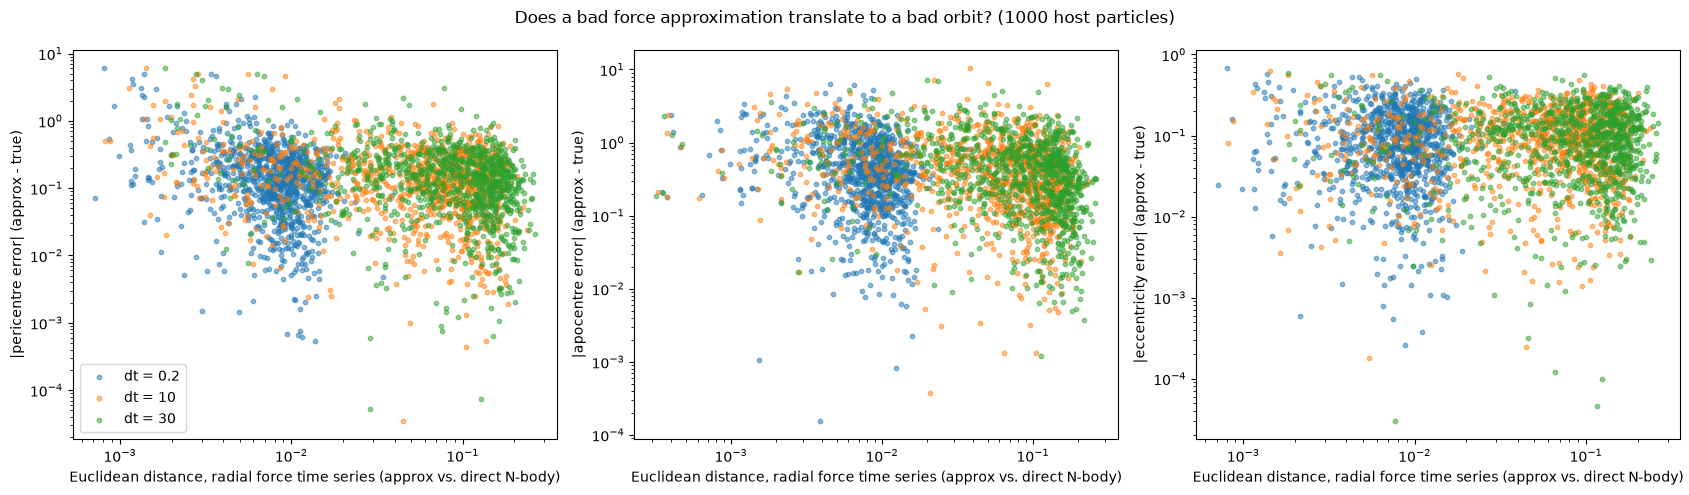

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(17, 5))

for label in CADENCES:
    dperi = np.abs(peri_approx[label] - peri_true)
    dapo = np.abs(apo_approx[label] - apo_true)
    decc = np.abs(ecc_approx[label] - ecc_true)
    fe = euclid_force_err[label]

    good_p = np.isfinite(dperi) & np.isfinite(fe) & (fe > 0) & (dperi > 0)
    axs[0].scatter(fe[good_p], dperi[good_p], s=10, alpha=0.5,
                   color=CADENCE_COLORS[label], label=f"dt = {label}")

    good_a = np.isfinite(dapo) & np.isfinite(fe) & (fe > 0) & (dapo > 0)
    axs[1].scatter(fe[good_a], dapo[good_a], s=10, alpha=0.5,
                   color=CADENCE_COLORS[label], label=f"dt = {label}")

    good_e = np.isfinite(decc) & np.isfinite(fe) & (fe > 0) & (decc > 0)
    axs[2].scatter(fe[good_e], decc[good_e], s=10, alpha=0.5,
                   color=CADENCE_COLORS[label], label=f"dt = {label}")

ylabels = ["|pericentre error| (approx - true)", "|apocentre error| (approx - true)",
          "|eccentricity error| (approx - true)"]
for ax, ylabel in zip(axs, ylabels):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Euclidean distance, radial force time series (approx vs. direct N-body)")
    ax.set_ylabel(ylabel)
axs[0].legend()
fig.suptitle("Does a bad force approximation translate to a bad orbit? (1000 host particles)")
fig.tight_layout()
fig.savefig("perturbed_host_bfe_ensemble_force_vs_orbit_error.png", dpi=150)


### What cadence do we need? Pericentre/eccentricity dependence

If a coarse cadence's errors were uniform across the population, a single "good enough" `dt`
would work for the whole host. But the coefficient interpolation only has to track the
perturber's fast passages *if* an orbit actually visits the region it affects -- so the cadence
needed for a faithful orbit likely depends on how deep/eccentric that orbit is. For each cadence
(marker shape *and* colour), plot the true pericentre distance and eccentricity of each of the
1000 particles against the *signed* difference between that cadence's estimate and the truth.


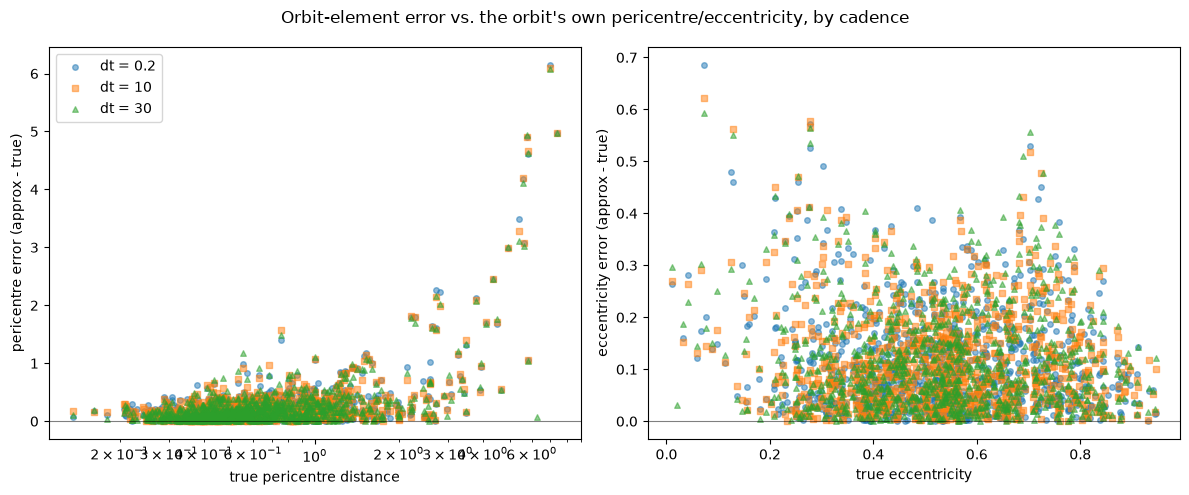

In [16]:
MARKERS = {"0.2": "o", "10": "s", "30": "^"}

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for label in CADENCES:
    dperi = np.sqrt((peri_approx[label] - peri_true)**2)
    decc = np.sqrt((ecc_approx[label] - ecc_true)**2)

    good_p = np.isfinite(dperi)
    axs[0].scatter(peri_true[good_p], dperi[good_p], s=16, alpha=0.5, marker=MARKERS[label],
                   color=CADENCE_COLORS[label], label=f"dt = {label}")

    good_e = np.isfinite(decc)
    axs[1].scatter(ecc_true[good_e], decc[good_e], s=16, alpha=0.5, marker=MARKERS[label],
                   color=CADENCE_COLORS[label], label=f"dt = {label}")

axs[0].set_xscale("log")
axs[0].set_xlabel("true pericentre distance")
axs[0].set_ylabel("pericentre error (approx - true)")
axs[1].set_xlabel("true eccentricity")
axs[1].set_ylabel("eccentricity error (approx - true)")
for ax in axs:
    ax.axhline(0, color="k", lw=0.8, alpha=0.5)
axs[0].legend()
fig.suptitle("Orbit-element error vs. the orbit's own pericentre/eccentricity, by cadence")
fig.tight_layout()
fig.savefig("perturbed_host_bfe_ensemble_cadence_dependence.png", dpi=150)


### Euclidean force-distance error vs. orbital period, by cadence

A cadence's coefficients are refit every `dt`; a particle whose own orbital period is much
longer than `dt` gets many coefficient snapshots per orbit, while one on a much shorter-period
orbit only gets a handful -- so the force error might depend on the orbit's period relative to
the cadence, not just on the orbit's pericentre/eccentricity. Three period estimates are used,
from cheapest/roughest to most direct:

1. **Kepler's third law from the apocentre**, $T_{\rm Kepler} = 2\pi r_{\rm apo}^{3/2}$
   (Henon units: $G = M_{\rm host} = 1$) -- a rough single-radius proxy that needs only the true
   apocentre (`apo_true`, already computed above), no orbit integration.
2. **Radial period**: the peri-apo-peri time, $t_{{\rm peri},1} - t_{{\rm peri},0}$, read
   directly off the true trajectory's pericentre passages (same method as
   `plummer_sphere_stream_sim.ipynb`'s `get_radial_and_azimuthal_periods`).
3. **Azimuthal (orbital) period**: the radial period rescaled by how much of a full $2\pi$
   revolution the orbital-plane angle actually swept between those two pericentre passages
   (same reference notebook; here `arctan2` replaces its `arctan` to avoid a quadrant ambiguity
   when the orbital-plane angle crosses $\pm\pi/2$).

Definitions 2 and 3 need at least two pericentre passages inside the 90-time-unit window used
throughout this notebook, so they are undefined (NaN) for wide, slow orbits that never complete
one; definition 1 has no such requirement and is defined for every particle with a finite
apocentre.


In [17]:
def radial_azimuthal_periods(orbit):
    """Peri-to-peri (radial) and 2*pi-rescaled (azimuthal) periods, per orbit in a batch.

    Same definitions as plummer_sphere_stream_sim.ipynb's get_radial_and_azimuthal_periods,
    generalized to a batched (multi-particle) gala Orbit: radial_period is the time between the
    first two identified pericentre passages, and azimuthal_period rescales it by how much of a
    full 2*pi the orbital-plane angle actually advanced over that interval. Uses arctan2 (not
    that notebook's arctan) to avoid a quadrant-sign ambiguity; nan for particles with fewer
    than two pericentre passages in the orbit's time span.
    """
    n_orb = np.asarray(orbit.x).shape[1]
    _, times = orbit.pericenter(func=None, return_times=True)
    x, y, t_arr = np.asarray(orbit.x), np.asarray(orbit.y), np.asarray(orbit.t)

    radial_period = np.full(n_orb, np.nan)
    azimuthal_period = np.full(n_orb, np.nan)
    for k in range(n_orb):
        t_peri = np.asarray(times[k])
        if len(t_peri) < 2:
            continue
        radial_period[k] = t_peri[1] - t_peri[0]
        idx0 = np.argmin((t_arr - t_peri[0]) ** 2)
        idx1 = np.argmin((t_arr - t_peri[1]) ** 2)
        delta_phi = np.abs(np.arctan2(y[idx1, k], x[idx1, k])
                           - np.arctan2(y[idx0, k], x[idx0, k]))
        if delta_phi > 0:
            azimuthal_period[k] = (2 * np.pi / delta_phi) * radial_period[k]
    return radial_period, azimuthal_period


if not HAVE_CACHE:
    T_kepler_apo = 2 * np.pi * apo_true ** 1.5  # Kepler's third law, G=M_host=1, true apocentre
    T_radial, T_azimuthal = radial_azimuthal_periods(true_orbit_ens)
else:
    T_kepler_apo = _cache["T_kepler_apo"]
    T_radial = _cache["T_radial"]
    T_azimuthal = _cache["T_azimuthal"]

PERIODS = {"Kepler (apocentre)": T_kepler_apo, "radial": T_radial, "azimuthal": T_azimuthal}
for name, T in PERIODS.items():
    finite = np.isfinite(T)
    msg = (f"range [{np.nanmin(T):.2f}, {np.nanmax(T):.2f}]" if finite.any() else "none finite")
    print(f"{name}: {finite.sum()}/{len(T)} finite, {msg}")


Kepler (apocentre): 988/1000 finite, range [2.83, 521.46]
radial: 963/1000 finite, range [0.14, 62.29]
azimuthal: 963/1000 finite, range [0.15, 30023.00]


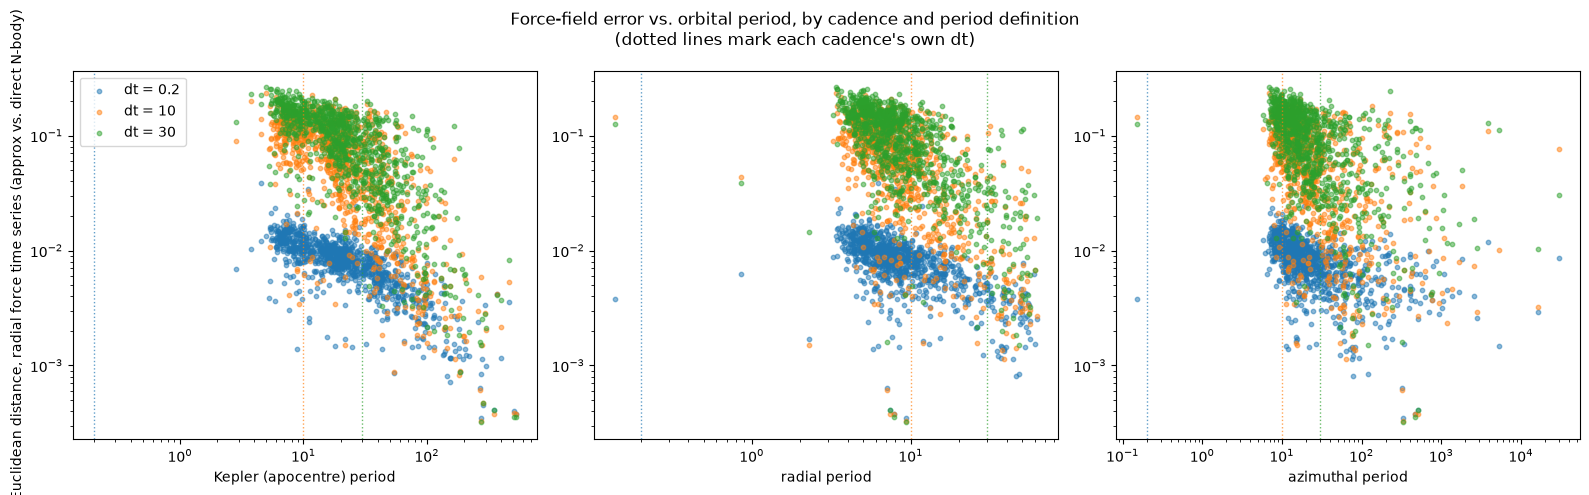

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, T) in zip(axs, PERIODS.items()):
    for label in CADENCES:
        fe = euclid_force_err[label]
        good = np.isfinite(T) & (T > 0) & np.isfinite(fe) & (fe > 0)
        ax.scatter(T[good], fe[good], s=10, alpha=0.5, color=CADENCE_COLORS[label],
                  label=f"dt = {label}")
        ax.axvline(float(label), color=CADENCE_COLORS[label], ls=":", lw=1, alpha=0.7)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"{name} period")
axs[0].set_ylabel("Euclidean distance, radial force time series (approx vs. direct N-body)")
axs[0].legend()
fig.suptitle("Force-field error vs. orbital period, by cadence and period definition\n"
            "(dotted lines mark each cadence's own dt)")
fig.tight_layout()
fig.savefig("perturbed_host_bfe_ensemble_force_error_vs_period.png", dpi=150)


## Orbit shape: discrete wavelet transform of the position time series

The pericentre/apocentre/eccentricity comparisons above reduce each orbit to three numbers,
averaged over every peri/apoapsis passage in the window -- exactly the kind of reduction that
can wash out a cadence-dependent force error (see the takeaways above). A discrete wavelet
transform (DWT) of the position time series keeps the *shape* of the orbit instead of collapsing
it: it decomposes $x(t)$, $y(t)$, $z(t)$ into coefficients at multiple time-scales
simultaneously, so a coarse cadence that gets the broad orbit right but misses fast, local
wiggles (or vice versa) shows up as a difference concentrated in specific coefficients rather
than being averaged away.

For each of the 1000 particles and each cadence:

1. Interpolate the true (N-body) trajectory and all three cadences' integrated orbits -- already
   host-COM-relative/comoving, the same frame used for the pericentre/apocentre/eccentricity
   comparisons above -- onto **one common, shared time grid** spanning the usual
   `[T_RELAX, 95]` window, so every DWT is computed from the same number of samples at the same
   times regardless of which potential produced the trajectory.
2. Run a multi-level DWT (`pywt.wavedec`, `db4`, level 4) on $x(t)$, $y(t)$, $z(t)$ separately
   and concatenate the three coefficient vectors into one per case.
3. RMSE between the N-body case's coefficient vector and each cadence's -- one scalar per
   particle per cadence, the same shape of quantity as the Euclidean force-distance used
   throughout this notebook, but describing the orbit's *shape* instead of the force *field*.

Requires `PyWavelets` (`pip install PyWavelets`), imported as `pywt`.


In [19]:
from scipy.interpolate import interp1d

N_DWT = 1024  # power of 2, convenient for multi-level wavelet decomposition
dwt_t_grid = np.linspace(t_inject, T_COMMON_MAX, N_DWT)

if not HAVE_CACHE:
    # True trajectory, interpolated onto the common grid (already host-COM-relative/comoving).
    pos_true_dwt = interp1d(true_t_ens, true_pos_ens_rel, axis=0)(dwt_t_grid)  # (N_DWT, N_SAMPLE, 3)

    # Each cadence's integrated orbit (also comoving -- see the integration cell above),
    # interpolated onto the SAME common grid so every case sees identical sample times.
    pos_approx_dwt = {}
    for label in CADENCES:
        orbit = orbits_ens[label]
        xyz = np.stack([np.asarray(orbit.x), np.asarray(orbit.y), np.asarray(orbit.z)], axis=-1)
        pos_approx_dwt[label] = interp1d(np.asarray(orbit.t), xyz, axis=0)(dwt_t_grid)
else:
    pos_true_dwt = _cache["pos_true_dwt"]
    pos_approx_dwt = {label: _cache[f"pos_approx_dwt_{label}"] for label in CADENCES}

print(f"common DWT grid: {N_DWT} points over t in [{dwt_t_grid[0]:.1f}, {dwt_t_grid[-1]:.1f}]")


common DWT grid: 1024 points over t in [5.0, 95.0]


In [20]:
import pywt

WAVELET = "db4"
DWT_LEVEL = 4

def dwt_coeffs(pos_series):
    """Flattened DWT coefficient vector for one particle: x(t), y(t), z(t) decomposed separately
    (same wavelet/level/grid for every case) and concatenated into a single vector."""
    coeffs = [pywt.wavedec(pos_series[:, k], WAVELET, level=DWT_LEVEL) for k in range(3)]
    return np.concatenate([c for coord_coeffs in coeffs for c in coord_coeffs])

if not HAVE_CACHE:
    dwt_rmse = {label: np.empty(N_SAMPLE) for label in CADENCES}
    for i in tqdm(range(N_SAMPLE), desc="DWT of orbit shape"):
        c_true = dwt_coeffs(pos_true_dwt[:, i, :])
        for label in CADENCES:
            c_approx = dwt_coeffs(pos_approx_dwt[label][:, i, :])
            dwt_rmse[label][i] = np.sqrt(np.mean((c_approx - c_true) ** 2))
else:
    dwt_rmse = {label: _cache[f"dwt_rmse_{label}"] for label in CADENCES}

for label in CADENCES:
    r = dwt_rmse[label]
    print(f"dt={label}: DWT-coefficient RMSE range [{r.min():.4f}, {r.max():.4f}], "
          f"median {np.median(r):.4f}")


dt=0.2: DWT-coefficient RMSE range [0.2936, 52.4891], median 1.4166
dt=10: DWT-coefficient RMSE range [0.3907, 54.5763], median 1.3460
dt=30: DWT-coefficient RMSE range [0.3958, 56.3001], median 1.3456


### Orbit-shape error vs. force-field error

Same style as the force-vs-orbit-element-error figure above, but the y-axis now tracks the
orbit's whole *shape* (the DWT-coefficient RMSE) instead of three reduced numbers.


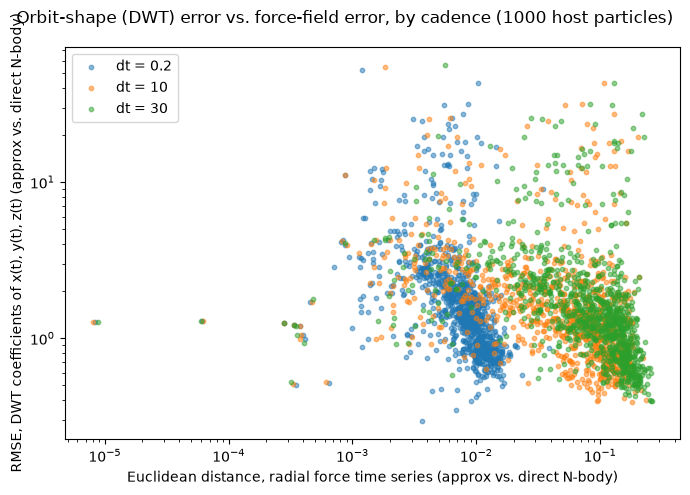

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
for label in CADENCES:
    fe = euclid_force_err[label]
    rmse = dwt_rmse[label]
    good = np.isfinite(fe) & (fe > 0) & np.isfinite(rmse) & (rmse > 0)
    ax.scatter(fe[good], rmse[good], s=10, alpha=0.5, color=CADENCE_COLORS[label],
              label=f"dt = {label}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Euclidean distance, radial force time series (approx vs. direct N-body)")
ax.set_ylabel("RMSE, DWT coefficients of x(t), y(t), z(t) (approx vs. direct N-body)")
ax.legend()
fig.suptitle("Orbit-shape (DWT) error vs. force-field error, by cadence (1000 host particles)")
fig.tight_layout()
fig.savefig("perturbed_host_bfe_ensemble_dwt_vs_force_error.png", dpi=150)


### Orbit-trajectory error vs. force-field error (raw position Euclidean distance)

A simpler complement to the DWT comparison above, using the exact same common-grid position
time series (`pos_true_dwt`, `pos_approx_dwt`) with no wavelet decomposition at all: just the
raw Euclidean distance between the N-body and each cadence's $x(t)$, $y(t)$, $z(t)$. For an
orthogonal wavelet like `db4`, Parseval's theorem means the DWT-coefficient L2 norm is close to
the signal's own L2 norm, so this is also a sanity check on whether the DWT step above changed
the picture at all, or just reproduced a plain trajectory comparison.


In [22]:
# Euclidean distance between position time series (approx vs. N-body) on the SAME common grid
# used for the DWT comparison above -- one scalar per particle per cadence, directly comparable
# to the Euclidean radial-force distance used throughout this notebook.
pos_euclid_err = {
    label: np.sqrt(np.sum((pos_approx_dwt[label] - pos_true_dwt) ** 2, axis=(0, 2)))
    for label in CADENCES
}
for label in CADENCES:
    d = pos_euclid_err[label]
    print(f"dt={label}: position Euclidean-distance range [{d.min():.3f}, {d.max():.3f}], "
          f"median {np.median(d):.3f}")


dt=0.2: position Euclidean-distance range [16.395, 2870.451], median 79.064
dt=10: position Euclidean-distance range [21.547, 2982.563], median 74.605
dt=30: position Euclidean-distance range [22.009, 3081.272], median 74.672


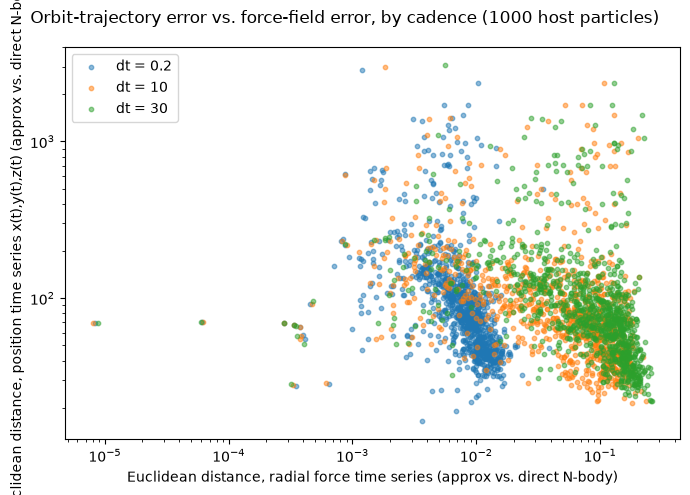

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
for label in CADENCES:
    fe = euclid_force_err[label]
    pe = pos_euclid_err[label]
    good = np.isfinite(fe) & (fe > 0) & np.isfinite(pe) & (pe > 0)
    ax.scatter(fe[good], pe[good], s=10, alpha=0.5, color=CADENCE_COLORS[label],
              label=f"dt = {label}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Euclidean distance, radial force time series (approx vs. direct N-body)")
ax.set_ylabel("Euclidean distance, position time series x(t),y(t),z(t) (approx vs. direct N-body)")
ax.legend()
fig.suptitle("Orbit-trajectory error vs. force-field error, by cadence (1000 host particles)")
fig.tight_layout()
fig.savefig("perturbed_host_bfe_ensemble_position_vs_force_error.png", dpi=150)


## Cross-correlation of the orbit time series

A third way to compare orbit shape, alongside the DWT and raw-position comparisons above: the
cross-correlation function between each cadence's $x(t)$, $y(t)$, $z(t)$ and the N-body
equivalent, on the same common grid (`dwt_t_grid`, reused directly -- no need to interpolate
again).

Summing the *signed* cross-correlation function over all lags turns out to be a degenerate
choice for an oscillating orbit: `scipy.signal.correlate(a, b, mode="full")` summed over every
lag is mathematically identical to `sum(a) * sum(b)` (shifting and adding one sequence against
the other and summing everything just re-sums each point of `b` once per point of `a`), and an
orbit that swings from one side of the host to the other averages close to zero over the
integration window regardless of cadence -- so the signed sum is numerically ~0 for most
particles and carries no information. Summing $|c(\mathrm{lag})|$ instead avoids that
cancellation while still reducing "the cross-correlation function" to a single scalar per
particle per cadence, comparable in kind to the DWT-RMSE and position-distance metrics above.


In [24]:
from scipy.signal import correlate

def cross_corr_sum_abs(pos_a, pos_b):
    """Sum of |cross-correlation function|, x(t)/y(t)/z(t) combined, for one particle's pair of
    position time series (both already on the common dwt_t_grid)."""
    return sum(np.abs(correlate(pos_a[:, k], pos_b[:, k], mode="full")).sum() for k in range(3))

if not HAVE_CACHE:
    cross_corr_sum = {label: np.empty(N_SAMPLE) for label in CADENCES}
    for i in tqdm(range(N_SAMPLE), desc="cross-correlation of orbit shape"):
        pos_true_i = pos_true_dwt[:, i, :]
        for label in CADENCES:
            cross_corr_sum[label][i] = cross_corr_sum_abs(pos_approx_dwt[label][:, i, :], pos_true_i)
else:
    cross_corr_sum = {label: _cache[f"cross_corr_sum_{label}"] for label in CADENCES}

for label in CADENCES:
    c = cross_corr_sum[label]
    print(f"dt={label}: sum(|cross-correlation|) range [{c.min():.3g}, {c.max():.3g}], "
          f"median {np.median(c):.3g}")


dt=0.2: sum(|cross-correlation|) range [1.68e+05, 4.6e+10], median 1.05e+06
dt=10: sum(|cross-correlation|) range [1.45e+05, 4.6e+10], median 9.83e+05
dt=30: sum(|cross-correlation|) range [1.4e+05, 4.6e+10], median 9.58e+05


### Cross-correlation vs. force-field error

Same style as the DWT and position-distance plots above.


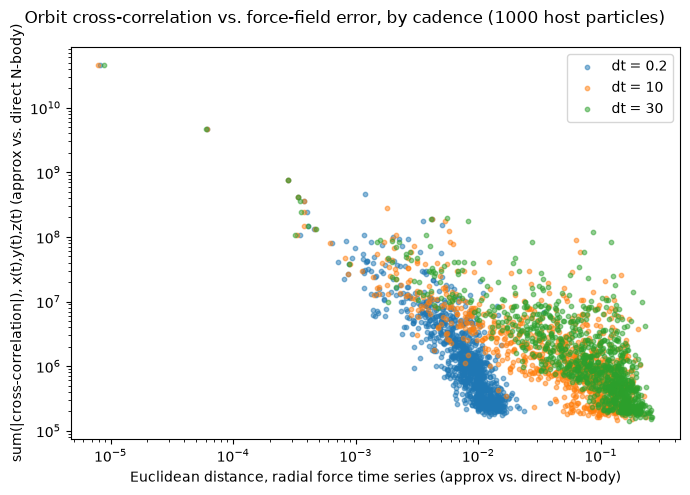

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
for label in CADENCES:
    fe = euclid_force_err[label]
    cc = cross_corr_sum[label]
    good = np.isfinite(fe) & (fe > 0) & np.isfinite(cc) & (cc > 0)
    ax.scatter(fe[good], cc[good], s=10, alpha=0.5, color=CADENCE_COLORS[label],
              label=f"dt = {label}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Euclidean distance, radial force time series (approx vs. direct N-body)")
ax.set_ylabel("sum(|cross-correlation|), x(t),y(t),z(t) (approx vs. direct N-body)")
ax.legend()
fig.suptitle("Orbit cross-correlation vs. force-field error, by cadence (1000 host particles)")
fig.tight_layout()
fig.savefig("perturbed_host_bfe_ensemble_crosscorr_vs_force_error.png", dpi=150)


In [26]:
if not HAVE_CACHE:
    np.savez(
        CACHE_FILE,
        peri_true=peri_true, apo_true=apo_true, ecc_true=ecc_true,
        **{f"peri_approx_{l}": peri_approx[l] for l in CADENCES},
        **{f"apo_approx_{l}": apo_approx[l] for l in CADENCES},
        **{f"ecc_approx_{l}": ecc_approx[l] for l in CADENCES},
        **{f"euclid_force_err_{l}": euclid_force_err[l] for l in CADENCES},
        T_kepler_apo=T_kepler_apo, T_radial=T_radial, T_azimuthal=T_azimuthal,
        pos_true_dwt=pos_true_dwt,
        **{f"pos_approx_dwt_{l}": pos_approx_dwt[l] for l in CADENCES},
        **{f"dwt_rmse_{l}": dwt_rmse[l] for l in CADENCES},
        **{f"pos_euclid_err_{l}": pos_euclid_err[l] for l in CADENCES},
        **{f"cross_corr_sum_{l}": cross_corr_sum[l] for l in CADENCES},
    )
    print(f"saved ensemble cache to {CACHE_FILE}")
else:
    print(f"used cached ensemble results from {CACHE_FILE} "
          "-- delete this file to force a full recompute")


used cached ensemble results from runs/point_mass/bfe/ensemble_cache.npz -- delete this file to force a full recompute


### Takeaways from the 1000-particle ensemble

**Force error does not cleanly predict orbit-element error.** In the first scatter, the three
cadences' point clouds mostly overlap and the pericentre/eccentricity error shows no strong
trend with the radial-force Euclidean distance (if anything, the largest force errors tend to
sit at *smaller* orbit-element errors) -- a large *instantaneous* force mismatch along a
particle's true path does not translate one-to-one into a large *orbit-integration* error,
likely because orbit-averaging and the direction (not just magnitude) of the force error both
matter, and a single scalar per particle washes that out.

**Cadence matters far less than which orbit you ask about.** The second plot's real message is
in what's missing: `dt=0.2`, `dt=10` and `dt=30` land almost on top of each other for every
particle. Coarsening the coefficient cadence from 0.2 to 30 -- a 150x reduction in how often the
BFE is refit -- barely changes the pericentre/eccentricity error at fixed orbit. What *does*
change the error by orders of magnitude is the orbit itself: pericentre errors stay small and
scattered for `r_peri <~ 1` (a scale radius) and blow up past `r_peri ~ 2-3` (reaching -5 to -6
at the largest pericentres probed), and eccentricity error is systematically positive at low
eccentricity and negative at high eccentricity. Since all three cadences share the *same static
sphereSL basis* -- only the coefficient refit frequency differs -- this points to the basis's
fixed spatial truncation (`lmax`, `nmax`, radial grid) as the dominant error source for these
wide/eccentric orbits, not the coefficient-sampling cadence this notebook set out to test.

**So: for this run, a coarse cadence (`dt=30`, coarser than the perturber's own orbital period)
is about as faithful to individual orbits as the finest one tested (`dt=0.2`) -- the fast
force-vs-time excursions the top of this notebook highlights near pericentre passages don't
appear to bottleneck single-particle orbit fidelity. The real lever for a faithful orbit
population appears to be basis completeness at large radius, which this experiment held fixed
across all three cadences and would need a separate `lmax`/`nmax`/`rmax` sweep to test.**

**Force error does separate cleanly by cadence once you condition on orbital period, though.**
Unlike the pericentre/eccentricity plots above -- where the three cadences sat on top of each
other -- plotting the same Euclidean force-distance against the orbit's own period (Kepler
estimate from the apocentre, radial, or azimuthal) splits the cadences into three clean,
mostly-non-overlapping bands (`dt=30` on top, `dt=0.2` on the bottom) for all three period
definitions. And within every cadence, the error falls off steadily as the period grows: short-
period particles stay deep in the host where the force is largest and most rapidly time-varying
(and, for the shortest ones, the softening-scale regime this basis resolves least well), while
long-period particles spend most of their time far out where the perturber's fast passages
matter less. So cadence *does* matter for the force field itself, roughly uniformly across the
population -- it just doesn't propagate into the pericentre/eccentricity errors above, which
seem to be set by something else (basis truncation) instead.

**Apocentre error is the key control here -- and it does *not* inherit the period plot's clean
separation.** Since the Kepler period estimate above is just $2\pi r_{\rm apo}^{3/2}$, one might
expect the *apocentre* error (added as the middle panel of the force-vs-orbit-error figure) to
show the same cadence-separated bands the period plot does. It doesn't: the apocentre-error
panel looks just like the pericentre and eccentricity panels either side of it -- `dt=0.2`,
`dt=10` and `dt=30` overlap, with no clean trend against the force-error magnitude. So the
split-by-cadence effect is not really about apocentre (or any single orbital element) at all --
it is about *which quantity is being measured*. The period plot's x-axis is the true period, a
single fixed number per particle, plotted against a *raw, instantaneous* force-field mismatch
sampled directly along the true trajectory. Pericentre, apocentre and eccentricity here, by
contrast, are gala's default `func=np.mean` reduction over *every* peri/apoapsis passage inside
the 90-time-unit integration window -- and a short-period particle contributes many passages to
that average, giving an oscillatory, cadence-driven force error many chances to cancel out
before it reaches the reported orbital element. Long-period particles contribute only one or two
passages (nothing to average away) but are exactly the ones with the smallest force error to
begin with. The two effects roughly cancel in the pericentre/apocentre/eccentricity plots, which
is why the force field itself is demonstrably cadence-sensitive (period plot) while the
*integrated, cycle-averaged* orbital elements this notebook set out to test largely are not.

**The DWT orbit-shape comparison lands closer to pericentre/apocentre/eccentricity than to the
force-vs-period plot.** The x-axis (Euclidean force-distance) still separates cleanly into three
per-cadence bands, as it does everywhere else in this notebook -- that part is robust. But the
y-axis (RMSE between the N-body and each cadence's DWT coefficients of $x(t)$, $y(t)$, $z(t)$)
is noisy and heavily overlapping across cadences at fixed force error, and the per-cadence
medians are nearly flat (`dt=0.2`: 1.42, `dt=10`: 1.35, `dt=30`: 1.35 in this run) rather than
monotonically increasing with cadence coarseness. The likely reason is the same
orbit-integration-washes-it-out mechanism as above: a length-1024 DWT is dominated by its
low-frequency approximation coefficients (the bulk shape of a 90-time-unit trajectory), and
those are set by each particle's overall dynamics -- itself sensitive to basis truncation and,
for short-period particles, to many cycles' worth of phase-mixing -- rather than by the
local, fast force-field noise a coarse cadence introduces. So: cadence clearly degrades the
*instantaneous* force field (x-axis, everywhere), but neither the reduced orbital elements nor
the full-shape DWT coefficients computed by *integrating* an orbit over many dynamical times
recover that signal cleanly -- only conditioning directly on the orbit's own (true) period does.

**Cross-correlation agrees with DWT and raw position distance, not with the period plot.**
`sum(|cross-correlation|)` falls off steadily as the force error grows -- the same
orbit-scale-driven trend as the DWT and raw-position comparisons -- but the three cadences
overlap heavily at fixed force error rather than splitting into clean bands. Three different
ways of comparing the *whole integrated trajectory* (DWT coefficients, raw Euclidean distance,
cross-correlation) now agree with each other and with the pericentre/apocentre/eccentricity
comparisons: cadence's effect on the force field doesn't survive being run through an orbit
integration, no matter which shape metric reads out the result afterward. Only conditioning
directly on the true orbital period recovers a clean cadence signal.

**On performance**: this ensemble section now caches its expensive intermediate results
(orbit integration, the ~900-snapshot true-trajectory read, the direct N-body force evaluation,
the DWT/position/cross-correlation arrays) to `runs/point_mass/bfe/ensemble_cache.npz` the first
time it runs (~20 minutes); every cell after the sampling step checks `HAVE_CACHE` and loads
from that file instead of recomputing if it exists, so adding one more statistic on top of these
takes seconds, not another 20-minute run. Delete the cache file to force a full recompute (e.g.
after changing `N_SAMPLE`, the sampling seed, or `T_COMMON_MAX` upstream).
